# Deep Learning Project: Predicting if a bank customer will exit the bank

## Importing the libraries

In [27]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

import wandb
from wandb.integration.keras import WandbMetricsLogger

from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

## set up wandb

In [28]:
!pip install wandb -q

In [29]:
wandb.login()


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


False

## Importing the dataset

In [30]:
dataset = pd.read_csv("Bank_Customers.csv")
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

#print(X)
#print(Y)

## Data preprocessing

### Splitting the data into train & test

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Replace missing data

In [32]:
from sklearn.impute import SimpleImputer

numerical_columns = [0, 3, 4, 5, 6, 9]
categorical_columns = [1, 2, 7, 8]

imputer = SimpleImputer(missing_values=np.nan, strategy="median")
imputer.fit(X_train[:, numerical_columns])
X_train[:, numerical_columns] = imputer.transform(X_train[:, numerical_columns])
X_test[:, numerical_columns] = imputer.transform(X_test[:, numerical_columns])

imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
imputer.fit(X_train[:, categorical_columns])
X_train[:, categorical_columns] = imputer.transform(X_train[:, categorical_columns])
X_test[:, categorical_columns] = imputer.transform(X_test[:, categorical_columns])


### One-hot encoding the geography & gender column

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[("encoder", OneHotEncoder(sparse_output=False), [1, 2])],
    remainder="passthrough",
)
X_train = np.array(ct.fit_transform(X_train))
X_test = np.array(ct.transform(X_test))

### Feature scaling

In [34]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Building the Nerual Network

#### A feedforward neural network is constructed with:


*   An input layer that receives the preprocessed feature vectors.
*   Two fully connected hidden layers (64 and 32 neurons) using the ReLU activation function.


*   One output layer with a single neuron using the Sigmoid activation function for binary classification.

#### The ReLU activation function is used in the hidden layers to introduce non-linearity and enable the network to learn complex patterns from the data. The Sigmoid activation function is applied in the output layer to produce probability values between 0 and 1, making it suitable for predicting binary outcomes.






### Initializing the ANN

In [35]:
model = tf.keras.models.Sequential()

### Adding the input layer and the first hidden layer

In [36]:
tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Dense name=dense_3, built=False>

### Adding the second hidden layer

In [37]:
model.add(tf.keras.layers.Dense(units=32, activation='relu'))

### Adding the output layer

In [38]:
model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

### Handling Class Imbalance



#### To address the low recall and class imbalance observed in Model 1, the loss function was changed from Binary Cross-Entropy to Focal Loss. Focal Loss is specifically designed for imbalanced classification tasks, as it reduces the impact of easily classified majority-class samples and focuses more on hard and minority-class examples.

#### Since the dataset contains significantly fewer positive cases, the baseline model favored the majority class, leading to many false negatives. By using Focal Loss, the model is encouraged to better learn from minority samples, aiming to improve recall while keeping the architecture unchanged.

In [39]:
def focal_loss(alpha=0.75, gamma=2.0):
    """
    Binary focal loss for imbalanced classification.
    alpha: balance factor for positive class
    gamma: focusing parameter (higher -> focus more on hard samples)
    """
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)

        eps = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)

        # pt = p if y=1 else (1-p)
        pt = tf.where(tf.equal(y_true, 1.0), y_pred, 1.0 - y_pred)

        # alpha_t = alpha if y=1 else (1-alpha)
        alpha_t = tf.where(tf.equal(y_true, 1.0), alpha, 1.0 - alpha)

        return -tf.reduce_mean(alpha_t * tf.pow(1.0 - pt, gamma) * tf.math.log(pt))
    return loss

### Compiling the ANN

#### The model is compiled using:


*   Adam optimizer with learning rate 0.001 for efficient gradient updates.
*   Binary Crossentropy loss, suitable for binary classification tasks.
*   Evaluation metrics including Accuracy, Precision, Recall, and AUC to comprehensively assess performance.



In [40]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss(alpha=0.75, gamma=2),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

## Training the ANN on the Training set

### Callbacks - Saving checkpoint

In [41]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
)

### Experiment Tracking Configuration (WandB)

In [42]:
RUN_NAME = "model_1_exp_1"

wandb.init(
    project="bank_customers_churn",
    name=RUN_NAME,
    config={
        "model_id": 2,
        "architecture": "64-32-relu + sigmoid",
        "epochs": 50,
        "batch_size": 128,
        "learning_rate": 0.001,
        "optimizer": "adam",
        "loss": "focal_loss",
        "alpha": 0.75,
        "gamma": 2.0
    }
)

wandb_callback = WandbMetricsLogger()

epoch/accuracy,▁▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇██████████████████
epoch/auc,▁▃▄▅▅▆▆▇▇▇▇▇▇███████████████████████████
epoch/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▄▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/precision,▁▃▆▇▇███████████████████████████████████
epoch/recall,▇▁▁▁▁▂▂▂▂▃▃▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇█▇█▇█▇██████
epoch/val_accuracy,▁▂▂▃▃▃▄▄▄▃▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▆██▇▇▆▆▇▇▇▇▇▇▇▇
epoch/val_auc,▁▃▄▄▅▆▆▆▆▇▇▇▇▇▇█████████████████████████
epoch/val_loss,█▆▅▅▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+2,...


### Train the model

In [43]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    callbacks=[checkpoint, wandb_callback]
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - accuracy: 0.4360 - auc: 0.4865 - loss: 0.0922 - precision: 0.2030 - recall: 0.6107 - val_accuracy: 0.5900 - val_auc: 0.5499 - val_loss: 0.0658 - val_precision: 0.2358 - val_recall: 0.4688
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6138 - auc: 0.5907 - loss: 0.0631 - precision: 0.2583 - recall: 0.4888 - val_accuracy: 0.6781 - val_auc: 0.6803 - val_loss: 0.0570 - val_precision: 0.3304 - val_recall: 0.5938
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.6887 - auc: 0.7075 - loss: 0.0555 - precision: 0.3446 - recall: 0.5634 - val_accuracy: 0.7337 - val_auc: 0.7269 - val_loss: 0.0540 - val_precision: 0.3891 - val_recall: 0.5813
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7223 - auc: 0.7501 - loss: 0.0534 - precision: 0.3978 - recall: 0.5842 - val_accuracy: 0.7519 - val_auc: 0.7517 - val_loss: 0.0522 - val_precision: 0.4150 - val_recall: 0.5875
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━

### Performance Visualization - Training and Validation Curves

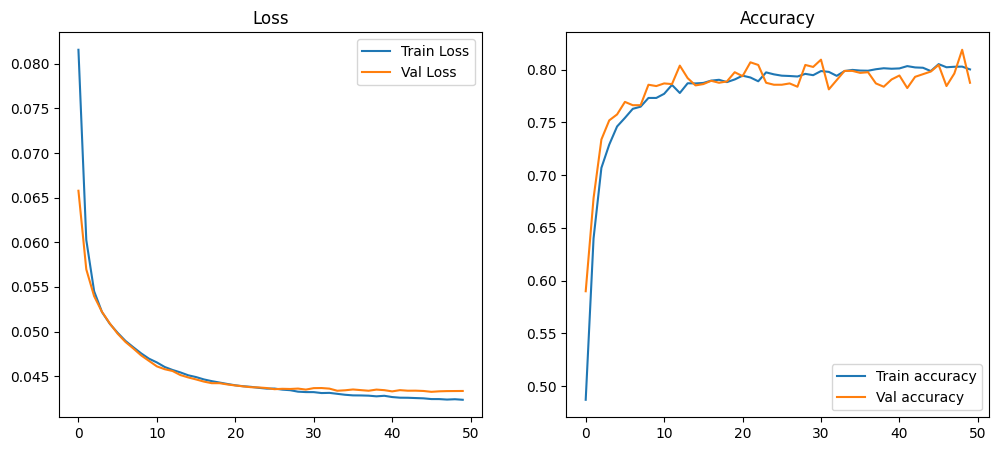

In [44]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.legend()
plt.title("Accuracy")

plt.show()

### Hyperparameters table

In [3]:
import pandas as pd

hyperparameters = {
    "Parameter": [
        "Model ID",
        "Hidden Layer 1 Units",
        "Hidden Layer 2 Units",
        "Activation Function (Hidden)",
        "Output Activation",
        "Optimizer",
        "Learning Rate",
        "Loss Function",
        "Focal Loss Alpha",
        "Focal Loss Gamma",
        "Batch Size",
        "Epochs"
    ],
    "Value": [
        "Model-1 (exp1)",
        64,
        32,
        "ReLU",
        "Sigmoid",
        "Adam",
        0.001,
        "Focal Loss",
        0.75,
        2.0,
        128,
        50
    ]
}

hp_table = pd.DataFrame(hyperparameters)
hp_table



,Parameter,Value
0,Model ID,Model-1 (exp1)
1,Hidden Layer 1 Units,64
2,Hidden Layer 2 Units,32
3,Activation Function (Hidden),ReLU
4,Output Activation,Sigmoid
5,Optimizer,Adam
6,Learning Rate,0.001
7,Loss Function,Focal Loss
8,Focal Loss Alpha,0.75
9,Focal Loss Gamma,2.0


## Predicting and evaluating the model


### Confusion Matrix Analysis

In [46]:
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Confusion Matrix:
 [[1306  287]
 [ 137  270]]


#### This means:


*   True Negatives (TN): 1306
*   False Positives (FP): 287
*   False Negatives (FN): 137
*   True Positives (TP): 270
#### The model performs very well in identifying the majority class (Class 0), but it struggles to correctly detect the minority class (Class 1).





### Performance metrics

In [47]:
results = model.evaluate(X_test, y_test, verbose=0)
print("Test Results (loss, acc, precision, recall, auc):\n", results)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC:", roc_auc)

Test Results (loss, acc, precision, recall, auc):
 [0.044310927391052246, 0.7879999876022339, 0.4847396910190582, 0.6633906364440918, 0.8366849422454834]

Classification Report:

              precision    recall  f1-score   support

           0     0.9051    0.8198    0.8603      1593
           1     0.4847    0.6634    0.5602       407

    accuracy                         0.7880      2000
   macro avg     0.6949    0.7416    0.7103      2000
weighted avg     0.8195    0.7880    0.7993      2000

ROC-AUC: 0.8367944215401844


### Plotting ROC Curve

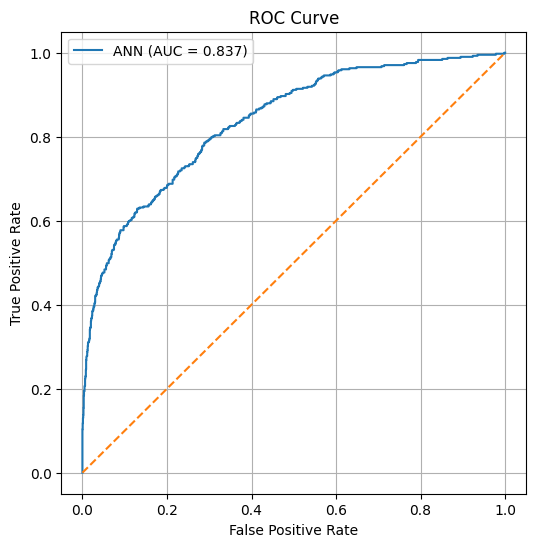

In [48]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ANN (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')  # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

## Impact of Applying Focal Loss (α = 0.75)

#### After modifying the loss function to Focal Loss with α = 0.75, the model’s behavior shifted noticeably toward better minority class detection.

### Recall Improvement

#### The recall for the churn class (Class 1) increased significantly to approximately 0.66, compared to the much lower recall observed in the baseline model.

#### This indicates that the model is now identifying a larger proportion of actual churned customers, effectively reducing False Negatives. Since churn prediction prioritizes detecting at-risk customers, this improvement is strategically valuable.

### Precision Trade-off

#### However, this improvement came at the cost of lower precision for the churn class (≈ 0.48).

#### This means the model now produces more False Positives, as it predicts churn more aggressively due to the higher importance assigned to minority-class samples.

#### This reflects the natural trade-off between precision and recall when handling imbalanced datasets.

### Macro F1-Score Analysis

#### The Macro F1-score (≈ 0.71) reflects balanced performance across both classes by treating them equally despite the class imbalance. The increase in minority-class recall improves overall class balance, but the lower precision limits further gains.

#### Overall, the macro F1-score indicates better sensitivity to the minority class, though some precision–recall trade-off remains.

### Overall Conclusion

#### In summary, increasing α in Focal Loss successfully improved minority class detection by prioritizing recall. While precision decreased and overall accuracy slightly dropped, the model now better aligns with the objective of identifying churned customers. Further tuning (e.g., threshold adjustment) could help achieve a better balance between recall and precision.